In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [3]:
# Load datasets
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
events = pd.read_csv("events.csv")
support = pd.read_csv("support_tickets.csv")
clv_labels = pd.read_csv("clv_labels.csv")
churn_labels = pd.read_csv("churn_labels.csv")

print(customers.head())
print(transactions.head())
print(events.head())
print(support.head())

   customer_id signup_date  age  gender country plan_type
0            1  2023-04-13   54  Female     USA     Basic
1            2  2024-03-11   53    Male   India     Basic
2            3  2025-05-10   41  Female  Canada   Premium
3            4  2023-09-28   48    Male  Canada     Basic
4            5  2023-04-17   23    Male     USA  Standard
   transaction_id  customer_id transaction_date  amount payment_method
0               1            1       2023-04-23  324.75           Card
1               2            1       2023-05-22  279.79            UPI
2               3            1       2023-06-13  247.26     NetBanking
3               4            1       2023-07-18  231.65         Wallet
4               5            1       2023-09-10  355.81     NetBanking
   event_id  customer_id  event_date      event_type
0         1            1  2023-11-06     video_watch
1         2            1  2024-09-27     video_watch
2         3            1  2025-05-25          search
3         4   

In [5]:
# Basic EDA
print(customers.info())
print(customers.isnull().sum())
print(transactions.describe())

# Convert date columns
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
events["event_date"] = pd.to_datetime(events["event_date"])
support["ticket_date"] = pd.to_datetime(support["ticket_date"])

# Observation date for recency and tenure
obs_date = pd.to_datetime("2026-01-01")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  1200 non-null   int64         
 1   signup_date  1200 non-null   datetime64[ns]
 2   age          1200 non-null   int64         
 3   gender       1200 non-null   object        
 4   country      1200 non-null   object        
 5   plan_type    1200 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 56.4+ KB
None
customer_id    0
signup_date    0
age            0
gender         0
country        0
plan_type      0
dtype: int64
       transaction_id  customer_id               transaction_date       amount
count     8928.000000  8928.000000                           8928  8928.000000
mean      4464.500000   607.048163  2024-09-10 22:03:23.225806336   535.419531
min          1.000000     1.000000            2023-01-01 00:00:00   176.100

In [6]:
# Transaction features - RFM
trans_features = transactions.groupby("customer_id").agg(
    total_spent=("amount", "sum"),
    avg_spent=("amount", "mean"),
    frequency=("transaction_id", "count"),
    last_transaction=("transaction_date", "max")
).reset_index()

trans_features["recency_days"] = (obs_date - trans_features["last_transaction"]).dt.days
trans_features.drop(columns=["last_transaction"], inplace=True)

In [7]:
# Event features
event_features = events.groupby("customer_id").agg(
    total_events=("event_id", "count"),
    active_days=("event_date", lambda x: x.dt.date.nunique())
).reset_index()

event_pivot = pd.crosstab(events["customer_id"], events["event_type"]).reset_index()
event_features = event_features.merge(event_pivot, on="customer_id", how="left")

In [8]:
# Support features
support_features = support.groupby("customer_id").agg(
    ticket_count=("ticket_id", "count"),
    avg_resolution_time=("resolution_time_hrs", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).reset_index()

In [9]:
# Merge all features
df = customers.merge(trans_features, on="customer_id", how="left")
df = df.merge(event_features, on="customer_id", how="left")
df = df.merge(support_features, on="customer_id", how="left")

df["tenure_days"] = (obs_date - df["signup_date"]).dt.days
df.drop(columns=["signup_date"], inplace=True)

df.fillna(0, inplace=True)

print(df.head())

   customer_id  age  gender country plan_type  total_spent   avg_spent  \
0            1   54  Female     USA     Basic      2326.06  290.757500   
1            2   53    Male   India     Basic      3533.10  294.425000   
2            3   41  Female  Canada   Premium     10157.72  923.429091   
3            4   48    Male  Canada     Basic       564.32  282.160000   
4            5   23    Male     USA  Standard      5166.48  574.053333   

   frequency  recency_days  total_events  ...  download  login  \
0        8.0         751.0            25  ...         0      7   
1       12.0         239.0            27  ...         1     12   
2       11.0        -186.0            24  ...         1      6   
3        2.0         765.0            16  ...         1      6   
4        9.0         683.0            27  ...         4      9   

   profile_update  search  subscription_page  video_watch  ticket_count  \
0               3       6                  1            8           0.0   
1       

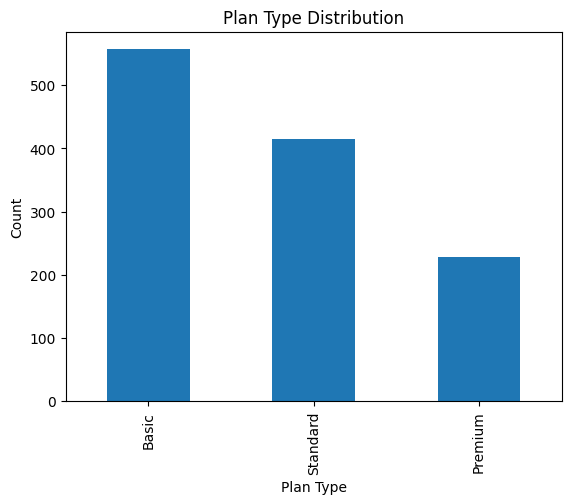

In [10]:
# EDA plots
plt.figure()
df["plan_type"].value_counts().plot(kind="bar")
plt.title("Plan Type Distribution")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.show()

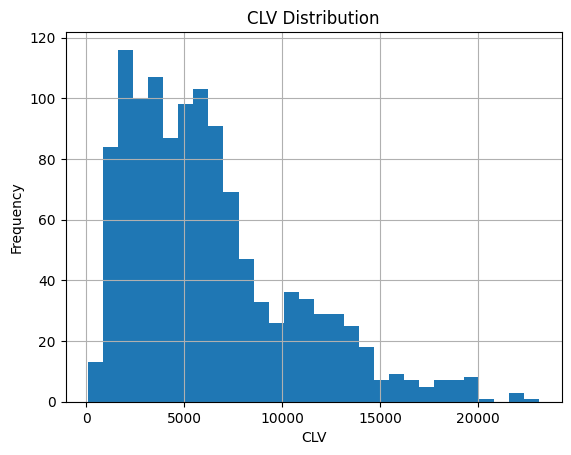

In [11]:
plt.figure()
clv_labels["clv"].hist(bins=30)
plt.title("CLV Distribution")
plt.xlabel("CLV")
plt.ylabel("Frequency")
plt.show()

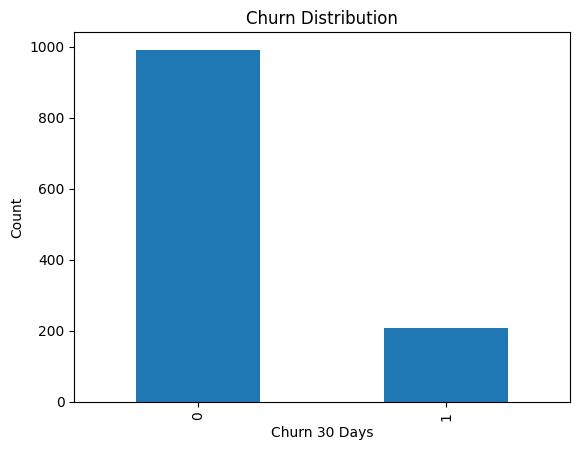

In [12]:
plt.figure()
churn_labels["churn_30d"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn 30 Days")
plt.ylabel("Count")
plt.show()

In [13]:
# CLV Prediction - Regression
clv_df = df.merge(clv_labels, on="customer_id", how="inner")

X = clv_df.drop(columns=["customer_id", "clv"])
y = clv_df["clv"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [15]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])
clv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clv_model.fit(X_train, y_train)
clv_pred = clv_model.predict(X_test)

In [17]:
print("CLV Regression Results")
print("MAE:", mean_absolute_error(y_test, clv_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, clv_pred)))
print("R2 Score:", r2_score(y_test, clv_pred))

CLV Regression Results
MAE: 345.51040791666634
RMSE: 461.6981633639702
R2 Score: 0.990461311088655


In [18]:
churn_df = df.merge(churn_labels, on="customer_id", how="inner")

X = churn_df.drop(columns=["customer_id", "churn_30d"])
y = churn_df["churn_30d"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [19]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

In [20]:
churn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

churn_model.fit(X_train, y_train)
churn_pred = churn_model.predict(X_test)
churn_prob = churn_model.predict_proba(X_test)[:, 1]

In [23]:
print("Churn Classification Results")
print("Accuracy:", accuracy_score(y_test, churn_pred))
print("ROC-AUC:", roc_auc_score(y_test, churn_prob))
print(classification_report(y_test, churn_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, churn_pred))

Churn Classification Results
Accuracy: 0.8208333333333333
ROC-AUC: 0.7547498797498797
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       198
           1       0.33      0.02      0.04        42

    accuracy                           0.82       240
   macro avg       0.58      0.51      0.47       240
weighted avg       0.74      0.82      0.75       240

Confusion Matrix
[[196   2]
 [ 41   1]]


In [24]:
# Insights
results = X_test.copy()
results["actual_churn"] = y_test.values
results["churn_probability"] = churn_prob
high_risk = results.sort_values("churn_probability", ascending=False).head(10)
print("Top 10 High Risk Customers")
print(high_risk[["churn_probability", "recency_days", "ticket_count", "avg_satisfaction", "frequency", "total_spent"]])

Top 10 High Risk Customers
      churn_probability  recency_days  ticket_count  avg_satisfaction  \
881               0.550         959.0           2.0          2.000000   
1020              0.505         763.0           1.0          4.000000   
130               0.505         844.0           0.0          0.000000   
537               0.500         818.0           3.0          3.333333   
573               0.480         906.0           0.0          0.000000   
367               0.475         876.0           2.0          2.000000   
474               0.465         868.0           1.0          4.000000   
1019              0.450         715.0           2.0          3.500000   
7                 0.445        1066.0           3.0          3.666667   
64                0.435         833.0           1.0          5.000000   

      frequency  total_spent  
881         3.0       909.05  
1020        5.0      1356.91  
130         7.0      1945.19  
537         1.0       266.59  
573         1.